# Week 4: Convolutional Variational Autoencoder (ConvVAE)

In this assignment, I implement a Convolutional Variational Autoencoder (ConvVAE) on the MNIST handwritten digits dataset.

The objectives are:

- Learn compressed latent representations of images
- Reconstruct images from latent vectors
- Generate new digits by sampling from the latent space
- Visualize the learned latent structure
- Explore the effect of different β values in β-VAE

Dataset: MNIST (28×28 grayscale handwritten digits)
Framework: PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Loading MNIST Dataset

In this section, we load the MNIST dataset and create training and testing dataloaders.

In [ ]:
# MNIST: 28×28 grayscale digits, values in [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),  # converts PIL image → tensor, scales to [0, 1]
])

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Sanity check
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # [128, 1, 28, 28]
print(f"Pixel range: [{images.min():.2f}, {images.max():.2f}]")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.10MB/s]

Batch shape: torch.Size([128, 1, 28, 28])
Pixel range: [0.00, 1.00]


## Building the ConvVAE

The ConvVAE consists of an encoder, latent space, and decoder. Convolutional layers are used for better image feature extraction.

In [ ]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=20, hidden_dims=None, kernel_size=3):
        """
        Args:
            latent_dim: size of the latent code z        # [PLAY]
            hidden_dims: list of channel sizes per layer # [PLAY] try [16,32,64] or [64,128,256]
            kernel_size: size of conv filters            # [PLAY] try 5
        """
        super().__init__()
        self.latent_dim = latent_dim
        if hidden_dims is None:
            hidden_dims = [32, 64, 128]  # [PLAY] ← change these three numbers!

        # ---- Encoder: 1×28×28 → latent distribution ----
        # Build encoder dynamically from hidden_dims list
        encoder_layers = []
        in_ch = 1
        for i, out_ch in enumerate(hidden_dims):
            # Last conv layer uses padding=0; others use padding=1
            pad = 0 if i == len(hidden_dims) - 1 else 1
            encoder_layers.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=2, padding=pad),
                nn.ReLU(),
            ])
            in_ch = out_ch
        encoder_layers.append(nn.Flatten())
        self.encoder = nn.Sequential(*encoder_layers)

        # Compute flattened size dynamically
        # After stride=2 three times: 28/2=14, 14/2=7, 7/2=3 (floor)
        # Last conv: kernel=3, stride=2, pad=0 on 7×7 → ceil((7-3+1)/2) = 3
        self.flattened_size = hidden_dims[-1] * 3 * 3
        self.last_channel   = hidden_dims[-1]  # for reshape in decode

        self.fc_mu    = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

        # ---- Decoder: latent → 1×28×28 ----
        self.decoder_input = nn.Linear(latent_dim, self.flattened_size)

        # Build decoder dynamically from reversed hidden_dims
        decoder_layers = []
        rev_dims = list(reversed(hidden_dims))
        for i in range(len(rev_dims) - 1):
            decoder_layers.extend([
                nn.ConvTranspose2d(rev_dims[i], rev_dims[i+1],
                                   kernel_size=4, stride=2, padding=1),
                nn.ReLU(),
            ])
        # Final layer: rev_dims[-1] → 1
        decoder_layers.extend([
            nn.ConvTranspose2d(rev_dims[-1], 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),  # output in [0, 1] to match input
        ])
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        """x: [B, 1, 28, 28] → mu: [B, latent_dim], logvar: [B, latent_dim]"""
        h = self.encoder(x)           # [B, flattened_size]
        mu = self.fc_mu(h)            # [B, latent_dim]
        logvar = self.fc_logvar(h)    # [B, latent_dim]
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Sample z = μ + σ · ε  (same trick as Week 3)"""
        std = torch.exp(0.5 * logvar)         # σ = exp(0.5 · log(σ²))
        eps = torch.randn_like(std)           # ε ~ N(0, I)
        return mu + eps * std

    def decode(self, z):
        """z: [B, latent_dim] → reconstruction: [B, 1, 24, 24]"""
        h = self.decoder_input(z)             # [B, flattened_size]
        h = h.view(-1, self.last_channel, 3, 3)   # reshape to [B, C_last, 3, 3]
        return self.decoder(h)                # [B, 1, 24, 24]

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

## VAE Loss Function

The total loss is the sum of reconstruction loss (BCE) and KL divergence.

In [ ]:
def vae_loss(recon, x, mu, logvar, beta=1.0):
    """
    recon:  [B, 1, 24, 24] -- decoder output
    x:      [B, 1, 28, 28] -- original image
    mu, logvar: [B, latent_dim]

    Returns: total_loss, recon_loss, kl_loss
    """
    # Resize reconstruction to match input size
    recon_resized = F.interpolate(recon, size=(28, 28), mode='bilinear')

    # Reconstruction: Binary Cross-Entropy (per-pixel)
    # We use reduction='sum' to match the KL term (also summed over latent dims)
    BCE = F.binary_cross_entropy(
        recon_resized, x, reduction='sum'
    )

    # KL Divergence: closed form (same as Week 2 & 3)
    # KL = -0.5 * sum(1 + log(σ²) - μ² - σ²)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total = BCE + beta * KLD
    return total, BCE, KLD

## Training the Model

Training the ConvVAE on MNIST using the Adam optimizer.

In [ ]:
def train_epoch(model, loader, optimizer, beta=1.0):
    model.train()
    total_loss, total_bce, total_kld = 0, 0, 0

    for x, _ in loader:  # we don't use labels
        x = x.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss, bce, kld = vae_loss(recon, x, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce  += bce.item()
        total_kld  += kld.item()

    n = len(loader.dataset)
    return total_loss / n, total_bce / n, total_kld / n


def evaluate(model, loader, beta=1.0):
    model.eval()
    total_loss, total_bce, total_kld = 0, 0, 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss, bce, kld = vae_loss(recon, x, mu, logvar, beta=beta)
            total_loss += loss.item()
            total_bce  += bce.item()
            total_kld  += kld.item()

    n = len(loader.dataset)
    return total_loss / n, total_bce / n, total_kld / n

In [ ]:
# ===== CONFIGURATION -- change these! =====
LATENT_DIM  = 20       # [PLAY] size of latent code z
LEARNING_RATE = 1e-3   # [PLAY] try 5e-4 or 3e-3
EPOCHS      = 30       # [PLAY] try 10, 50, 100
BETA        = 1.0      # [PLAY] KL weight -- try 0.1, 0.5, 2.0
# ==========================================

model = ConvVAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

epochs = EPOCHS
history = {"train_loss": [], "train_bce": [], "train_kld": [],
           "test_loss":  [], "test_bce":  [], "test_kld":  []}

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train BCE':>12} {'Train KLD':>12} "
      f"{'Test Loss':>12} {'Test BCE':>12} {'Test KLD':>12}")

print("-" * 78)

for epoch in range(1, epochs + 1):
    train_l, train_b, train_k = train_epoch(model, train_loader, optimizer, beta=BETA)
    test_l, test_b, test_k = evaluate(model, test_loader, beta=BETA)

    history["train_loss"].append(train_l)
    history["train_bce"].append(train_b)
    history["train_kld"].append(train_k)
    history["test_loss"].append(test_l)
    history["test_bce"].append(test_b)
    history["test_kld"].append(test_k)

    print(f"{epoch:>6} {train_l:>12.2f} {train_b:>12.2f} {train_k:>12.2f} "
          f"{test_l:>12.2f} {test_b:>12.2f} {test_k:>12.2f}")

print("\nTraining complete!")

 Epoch   Train Loss    Train BCE    Train KLD    Test Loss     Test BCE     Test KLD
------------------------------------------------------------------------------
     1       177.96       164.51        13.46       119.14        98.27        20.87
     2       113.59        91.13        22.47       109.34        86.04        23.30
     3       108.66        85.46        23.19       106.91        83.79        23.12
     4       106.74        83.36        23.38       105.53        81.88        23.65
     5       105.60        82.23        23.38       104.50        81.42        23.08
     6       104.76        81.44        23.32       104.16        81.66        22.51
     7       104.15        80.91        23.24       103.74        80.12        23.62
     8       103.59        80.39        23.20       102.88        79.47        23.41
     9       103.23        80.12        23.12       102.75        79.12        23.63
    10       102.86        79.76        23.10       102.32        80.11

## Training Curves

Plotting BCE loss and KL divergence across training epochs.

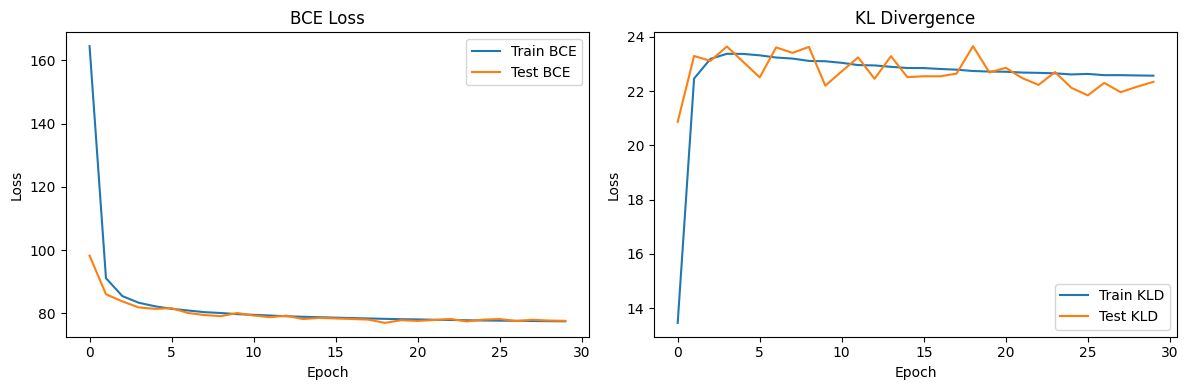

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history["train_bce"], label="Train BCE")
plt.plot(history["test_bce"], label="Test BCE")
plt.title("BCE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_kld"], label="Train KLD")
plt.plot(history["test_kld"], label="Test KLD")
plt.title("KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Image Reconstruction

Comparing original images with their reconstructed versions.

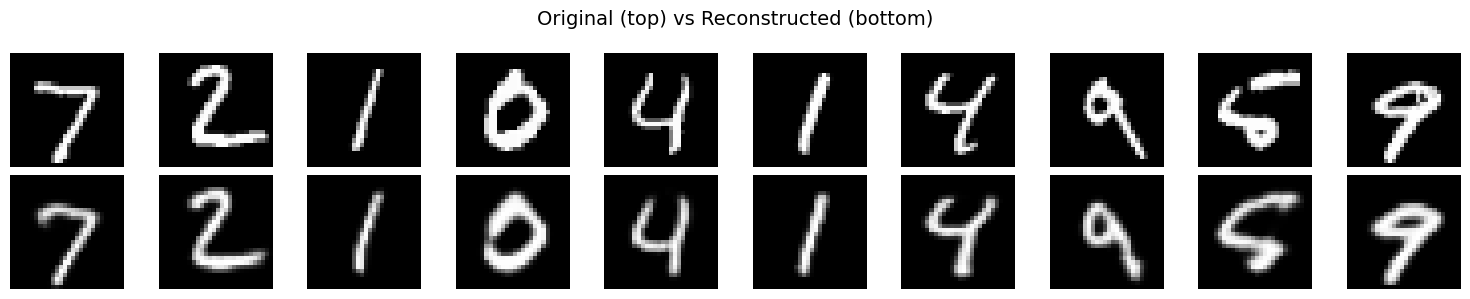

In [ ]:
@torch.no_grad()
def show_reconstructions(model, loader, n=10):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    recon, _, _ = model(x)
    recon = F.interpolate(recon, size=(28, 28), mode='bilinear')

    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i, 0].cpu(), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
    plt.suptitle("Original (top) vs Reconstructed (bottom)", fontsize=14)
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, n=10)

## Generating New Digits

Sampling random latent vectors and generating new digit images.

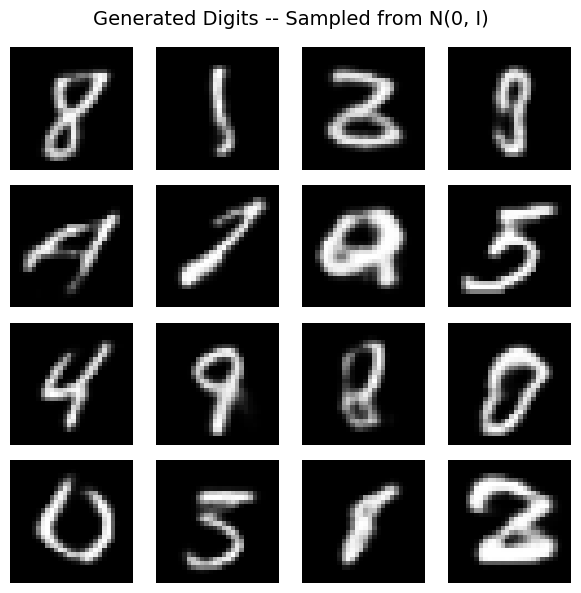

In [ ]:
@torch.no_grad()
def generate_digits(model, n=16, latent_dim=20):
    model.eval()
    # Sample z from the prior: N(0, I)
    z = torch.randn(n, latent_dim).to(device)
    samples = model.decode(z)
    samples = F.interpolate(samples, size=(28, 28), mode='bilinear')

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, 0].cpu(), cmap='gray')
        ax.axis('off')
    plt.suptitle("Generated Digits -- Sampled from N(0, I)", fontsize=14)
    plt.tight_layout()
    plt.show()

generate_digits(model, n=16)

## Latent Space Visualization

Using t-SNE to visualize the learned latent representations.

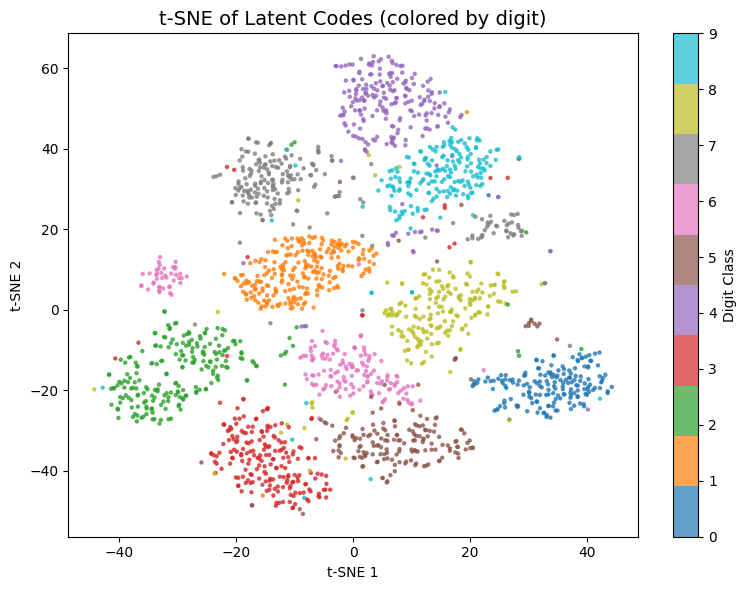

In [ ]:
from sklearn.manifold import TSNE

@torch.no_grad()
def plot_latent_tsne(model, loader, n_samples=2000):
    model.eval()
    all_z = []
    all_labels = []

    for x, y in loader:
        x = x.to(device)
        mu, _ = model.encode(x)
        all_z.append(mu.cpu())
        all_labels.append(y)
        if len(torch.cat(all_z)) >= n_samples:
            break

    z = torch.cat(all_z)[:n_samples].numpy()
    labels = torch.cat(all_labels)[:n_samples].numpy()

    # t-SNE to 2D
    z_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(z)

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10',
                         s=5, alpha=0.7)
    plt.colorbar(scatter, label="Digit Class")
    ax.set_title("t-SNE of Latent Codes (colored by digit)", fontsize=14)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

plot_latent_tsne(model, test_loader)

## Latent Space Interpolation

Interpolating between two latent vectors to observe smooth transitions between digits.

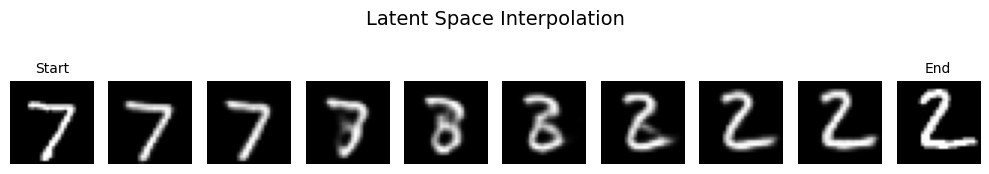

In [ ]:
@torch.no_grad()
def interpolate(model, loader, latent_dim=20, steps=8):
    model.eval()
    x, _ = next(iter(loader))

    # Take two real images
    img1 = x[0:1].to(device)
    img2 = x[1:2].to(device)

    # Get their latent codes
    mu1, _ = model.encode(img1)
    mu2, _ = model.encode(img2)

    # Interpolate
    alphas = torch.linspace(0, 1, steps).to(device)
    interpolations = []
    for alpha in alphas:
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        recon = model.decode(z_interp)
        recon = F.interpolate(recon, size=(28, 28), mode='bilinear')
        interpolations.append(recon)

    # Plot
    fig, axes = plt.subplots(1, steps + 2, figsize=(steps + 2, 2))
    axes[0].imshow(img1[0, 0].cpu(), cmap='gray')
    axes[0].set_title("Start", fontsize=10)
    axes[0].axis('off')

    for i, recon in enumerate(interpolations):
        axes[i+1].imshow(recon[0, 0].cpu(), cmap='gray')
        axes[i+1].axis('off')

    axes[-1].imshow(img2[0, 0].cpu(), cmap='gray')
    axes[-1].set_title("End", fontsize=10)
    axes[-1].axis('off')

    plt.suptitle("Latent Space Interpolation", fontsize=14)
    plt.tight_layout()
    plt.show()

interpolate(model, test_loader, steps=8)

## β-VAE Experiments

Comparing generated samples for different values of β.


--- Training with β = 0.0 ---
β = 0.0


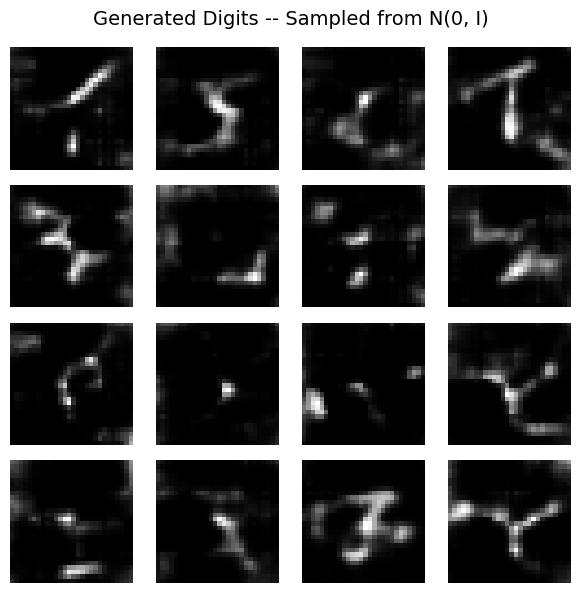


--- Training with β = 0.5 ---
β = 0.5


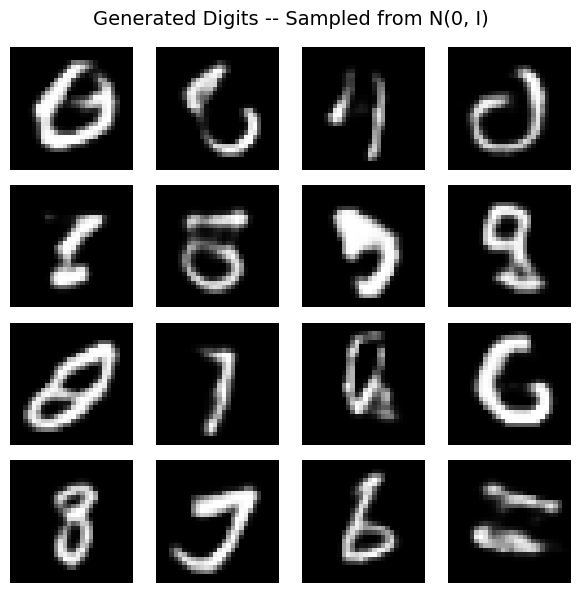


--- Training with β = 2.0 ---
β = 2.0


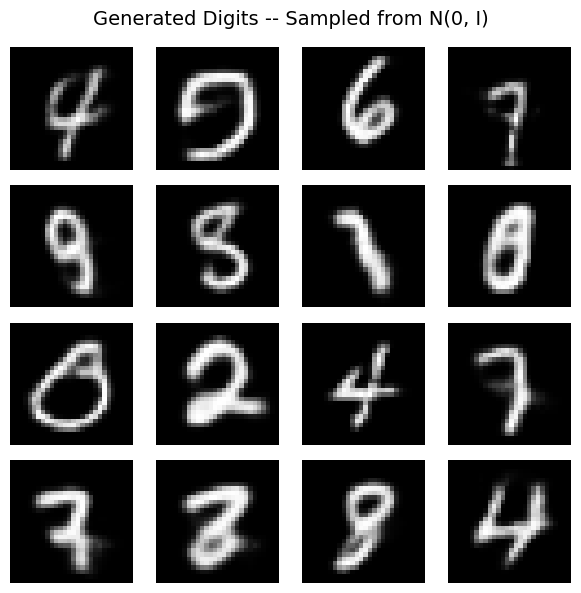

In [ ]:
betas = [0.0, 0.5, 2.0]

for beta in betas:
    print(f"\n--- Training with β = {beta} ---")

    model_b = ConvVAE(latent_dim=20).to(device)
    opt_b = optim.Adam(model_b.parameters(), lr=1e-3)

    for epoch in range(1, 21):
        train_epoch(model_b, train_loader, opt_b, beta=beta)

    print(f"β = {beta}")
    generate_digits(model_b, n=16)

## Conclusion

Implemented a ConvVAE on MNIST, explored latent space representations, generated new digits, performed interpolation, and studied the effect of β on model behavior.

As β increases, the KL divergence term receives more weight, forcing the latent representations to follow a standard normal distribution more closely. For β = 0.0, the generated samples are noisy and less structured because the model focuses mainly on reconstruction. For β = 0.5, the generated digits are clearer and more recognizable, providing a good balance between reconstruction quality and latent space regularization. For β = 2.0, the latent space becomes more organized and the generated digits are smoother, although some fine details may be lost due to stronger regularization.